# A-H Share Premium — the quant teardown 🇨🇳

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cheap H the better buy?: Busted](https://img.shields.io/badge/Cheap_H_the_better_buy%3F-Busted-8b949e?style=flat-square)

**Claim.** The same company costs ~30% more in Shanghai (A, CNY) than in Hong Kong (H, HKD), and no one can arbitrage it away.

**Design.** 14 dual-listed pairs (1:1-par ordinary shares, identical per-share dividends), 2010-01 → 2026-06. Premium = raw `A / (H × HKD→CNY) − 1` (the Hang Seng AHP convention), equal-weight, monthly. Return races use dividend-adjusted closes, H leg converted to CNY (total-return, one currency). ONE documented lag everywhere: month-end signal, next-month holding. Survivorship (still-dual-listed mega-cap panel) named on the Signal axis.

> 💡 **In plain words.** We measure the gap, test whether it ever closes, test whether it predicts which line does better, and then walk the arbitrage's locked doors one by one.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from a_h_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSE, ADJ = data.load_real()
    PREM_M = st.monthly_premium(st.premium_panel(CLOSE))
    REL_M = st.monthly_rel_returns(ADJ)
    EW = PREM_M.mean(axis=1).dropna()
else:
    CLOSE = ADJ = PREM_M = REL_M = EW = None
print("real A-H cache present:", HAVE_REAL,
      "| months:", (0 if EW is None else len(EW)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-01', 'end': '2026-06-30', 'years': 16.5, 'n_pairs': 14, 'n_months': 198, 'mean_pct': 29.69, 'hac12_t': 5.12, 'hac36_t': 3.29, 'share_pos': 84.8, 'last_neg': '2014-10', 'asof_pct': 33.1, 'min_pct': -11.7, 'max_pct': 77.1, 'post_mean': 41.9, 'post_t': 9.19, 'post_n': 139, 'n_pairs_pos': 13, 'widest': ('Great Wall Motor', 83.6), 'second': ('China Life', 74.5), 'narrowest': ('Ping An Insurance', -0.5), 'mc': [('calibrated AR(1) (phi 0.977, innov sd 0.0501)', 0.0177, 0.089), ('stress phi = 0.995', 0.2372, 0.2712), ('random walk from the 2010 start', 0.4405, 0.5118)], 'phi': 0.977, 'se_phi': 0.015, 'half_life': 30.4, 'df_t': -1.49, 'df_crit': -2.86, 'hl_median': 11.3, 'hl_min': 5.5, 'hl_max': 45.1, 'pair_corr': 0.322, 'pc1': 39.2, 'indep': 7.1, 'cm_months': 176, 'fade': [('gross, headline', 61.9, 5.09), ('skip-a-month', 45.5, 4.84), ('2010-01 - 2018-06', 84.9, 5.17), ('2018-07 - 2026-06', 36.4, 2.36), ('ex 2 extremes (GWM, China Life)', 60.5, 6.32), ('price-only (no dividends)', 64.1, 5.38), ('random halves (20-seed baseline)', -2.6, -0.26), ('z-portfolio', 63.5, 5.04), ('own-history time-series fade', 43.0, 1.39), ('unconditional carry (long H / short A)', 6.8, 0.26)], 'fade_ann': 7.68, 'fade_churn': 11.4, 'feas': [('gross', 54.7, 2.09), ('net 25 bps + 1.5%/yr borrow', 30.9, 1.19), ('net 50 bps + 3.0%/yr borrow', 7.1, 0.27), ('gross 2010-01 - 2018-06', 82.7, 1.91), ('gross 2018-07 - 2026-06', 24.9, 0.95)], 'feas_net_ann': 3.77, 'h_ann': 9.36, 'a_ann': 8.13, 'h_wealth': 4.35, 'a_wealth': 3.61, 'race_bps': 11.6, 'race_t': 0.42, 'race_years': 16.4, 'syn_level': [(30.0, 29.79, 0, 40), (0.0, -0.21, 0, 26)], 'syn_fade': [(0.97, 5.01), (1.0, 0.44)], 'fingerprint': 'f54aaa8986a9'}


real A-H cache present: True | months: 198


## 1 · The level — and why an HAC *t* is not enough here

The equal-weight premium averaged **+29.69%** (HAC(12) *t* = 5.12, HAC(36) *t* = 3.29). But the level has AR(1) φ = 0.977 — near-unit-root — and our own synthetic control shows **26/40 zero-mean worlds fake |HAC *t*| ≥ 2** on such a level. So the level claim gets a **Monte-Carlo placebo**: zero-mean paths with the tape's own persistence and innovation vol.

> 💡 **In plain words.** A wandering gap that mean-nothing could *look* significant by the usual test. We simulate thousands of such wanderers and ask how often they fake 16 years averaging +30%.

EW mean +29.69%  HAC(12) t +5.12  HAC(36) t +3.29  share>0 84.8%  (13/14 pairs positive)
post-Connect: mean +41.90%  HAC t +9.19  100% of 139 months positive


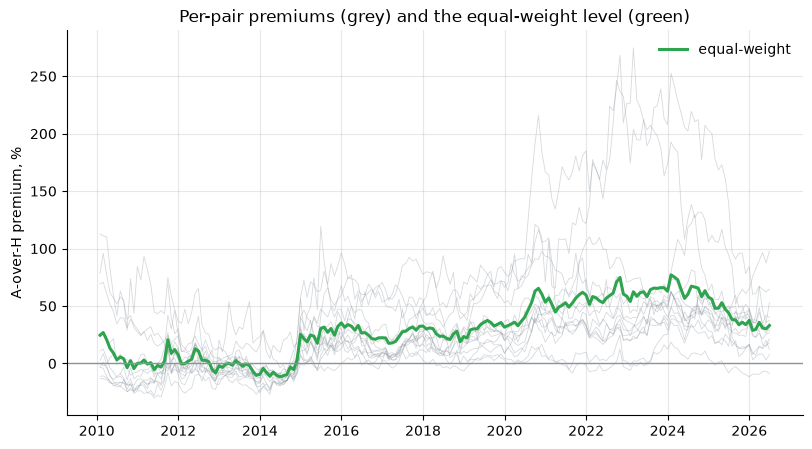

In [2]:
if HAVE_REAL:
    lv = st.level_stats(PREM_M, lags=12)
    _m36, _s36, t36 = st.nw_tstat(lv['ew'], lags=36)
    print(f"EW mean {lv['mean_pct']:+.2f}%  HAC(12) t {lv['hac_t']:+.2f}  "
          f"HAC(36) t {t36:+.2f}  share>0 {lv['share_pos']*100:.1f}%  "
          f"({lv['n_pairs_pos']}/{lv['n_pairs']} pairs positive)")
    post = lv['ew'].loc['2014-12':]
    pmu, _s, pt = st.nw_tstat(post, lags=12)
    print(f"post-Connect: mean {pmu*100:+.2f}%  HAC t {pt:+.2f}  "
          f"{int((post > 0).mean()*100)}% of {len(post)} months positive")
    fig, ax = plt.subplots()
    for c in PREM_M.columns:
        ax.plot(PREM_M.index, PREM_M[c] * 100, color=GREY, lw=0.6, alpha=0.35)
    ax.plot(lv['ew'].index, lv['ew'] * 100, color=GREEN, lw=2.2, label='equal-weight')
    ax.axhline(0, color=GREY, lw=1)
    ax.legend(frameon=False)
    ax.set_title('Per-pair premiums (grey) and the equal-weight level (green)')
    ax.set_ylabel('A-over-H premium, %')
    plt.show()

In [3]:
if HAVE_REAL:
    # Monte-Carlo placebo: zero-mean nulls with the tape's own dynamics (4,000 paths)
    rows = []
    for lbl, kw in [('calibrated AR(1)', {}), ('stress phi = 0.995', {'phi_override': 0.995}),
                    ('random walk from 2010 start', {'rw': True})]:
        mc = st.null_mc_level(EW, n_sims=4000, **kw)
        rows.append((lbl, mc['p_mean'], mc['p_share']))
        print(f"{lbl:30s}: p(mean >= {mc['obs_mean_pct']:+.1f}%) = {mc['p_mean']:.4f}   "
              f"p(share_pos >= {mc['obs_share']*100:.0f}%) = {mc['p_share']:.4f}")
    print()
    print('calibrated null rejects at 5%; the pure-RW stress null does NOT —')
    print('non-convergence is precisely what makes the level hard to certify,')
    print('and precisely the claim. Structure is certified by the RETURN-based')
    print('cross-section below (HAC t = +5.09 on returns).')

calibrated AR(1)              : p(mean >= +29.7%) = 0.0177   p(share_pos >= 85%) = 0.0890


stress phi = 0.995            : p(mean >= +29.7%) = 0.2372   p(share_pos >= 85%) = 0.2712


random walk from 2010 start   : p(mean >= +29.7%) = 0.4405   p(share_pos >= 85%) = 0.5118

calibrated null rejects at 5%; the pure-RW stress null does NOT —
non-convergence is precisely what makes the level hard to certify,
and precisely the claim. Structure is certified by the RETURN-based
cross-section below (HAC t = +5.09 on returns).


## 2 · Non-convergence — the premium vs a random walk

> 💡 **In plain words.** If arbitrage worked even slowly, the gap would drift back toward zero and a unit-root test would see it. It doesn't.

In [4]:
if HAVE_REAL:
    ar = st.ar1_stats(EW)
    print(f"AR(1) phi = {ar['phi']:.3f} (se {ar['se_phi']:.3f})  ->  "
          f"half-life {ar['half_life_m']:.1f} months")
    print(f"Dickey-Fuller t = {ar['df_t']:+.2f} vs 5% critical {ar['df_crit']:.2f}"
          f"  ->  cannot reject a unit root")
    hl = st.per_pair_half_lives(PREM_M)
    print(f"per-pair half-lives: median {hl.median():.1f} m, "
          f"range {hl.min():.1f} - {hl.max():.1f}")
    cm = st.comovement(PREM_M)
    print(f"co-movement: mean pairwise corr of changes {cm['mean_pair_corr']:.3f}; "
          f"PC1 {cm['pc1_share']*100:.1f}% of variance "
          f"(vs {100/cm['n_pairs']:.1f}% if independent)")

AR(1) phi = 0.977 (se 0.015)  ->  half-life 30.4 months
Dickey-Fuller t = -1.49 vs 5% critical -2.86  ->  cannot reject a unit root
per-pair half-lives: median 11.3 m, range 5.5 - 45.1
co-movement: mean pairwise corr of changes 0.322; PC1 39.2% of variance (vs 7.1% if independent)


## 3 · The fade — the cross-section mean-reverts even though the level never does

Long H / short A in the widest-premium half, the reverse in the narrow half; month-end signal, next-month holding, 0.5× per spread side.

> 💡 **In plain words.** No pair's premium reverts to *its own* past — but pairs revert to the *pack*. The pack itself just sits 30–40% above parity.

gross         : +61.9 bps/mo  HAC t +5.09  (ann +7.68%, churn 11.4%/mo)
skip-a-month  : +45.5 bps/mo  HAC t +4.84


2010-01 - 2018-06: +84.9 bps/mo  HAC t +5.17


2018-07 - 2026-06: +36.4 bps/mo  HAC t +2.36
price-only    : +64.1 bps/mo  HAC t +5.38  (not a dividend-carry artefact)
random halves : -2.6 bps/mo  mean t -0.26  (20 seeds)
own-history TS: +43.0 bps/mo  HAC t +1.39
uncond. carry : +6.8 bps/mo  HAC t +0.26


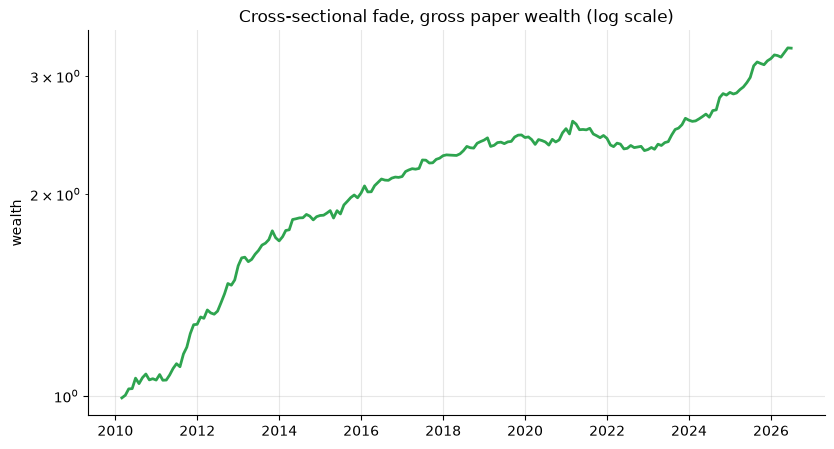

In [5]:
if HAVE_REAL:
    f0 = st.fade_cross_section(PREM_M, REL_M)
    fs = st.fade_cross_section(PREM_M.shift(1), REL_M)
    rel_po = st.monthly_rel_returns_price_only(CLOSE)
    fpo = st.fade_cross_section(PREM_M, rel_po)
    rb = st.fade_random_baseline(PREM_M, REL_M, n_seeds=20)
    ts = st.fade_time_series(PREM_M, REL_M)
    cy = st.carry_stats(REL_M)
    print(f"gross         : {f0['mean_bps']:+.1f} bps/mo  HAC t {f0['hac_t']:+.2f}  "
          f"(ann {f0['ann_pct']:+.2f}%, churn {f0['avg_churn']*100:.1f}%/mo)")
    print(f"skip-a-month  : {fs['mean_bps']:+.1f} bps/mo  HAC t {fs['hac_t']:+.2f}")
    for lo, hi in [('2010-01', '2018-06'), ('2018-07', '2026-06')]:
        f2 = st.fade_cross_section(PREM_M.loc[lo:hi], REL_M.loc[lo:hi])
        print(f"{lo} - {hi}: {f2['mean_bps']:+.1f} bps/mo  HAC t {f2['hac_t']:+.2f}")
    print(f"price-only    : {fpo['mean_bps']:+.1f} bps/mo  HAC t {fpo['hac_t']:+.2f}  "
          f"(not a dividend-carry artefact)")
    print(f"random halves : {rb['mean_bps']:+.1f} bps/mo  mean t {rb['mean_t']:+.2f}  "
          f"({rb['n_seeds']} seeds)")
    print(f"own-history TS: {ts['mean_bps']:+.1f} bps/mo  HAC t {ts['hac_t']:+.2f}")
    print(f"uncond. carry : {cy['mean_bps']:+.1f} bps/mo  HAC t {cy['hac_t']:+.2f}")
    fig, ax = plt.subplots()
    ax.plot(f0['ret'].index, (1 + f0['ret']).cumprod(), color=GREEN, lw=2)
    ax.set_title('Cross-sectional fade, gross paper wealth (log scale)')
    ax.set_yscale('log'); ax.set_ylabel('wealth')
    plt.show()

## 4 · Tradability — walking the locked doors

The wide half of the fade is long H / **short A** — and there is **no A-share borrow**: the lines are non-fungible, Stock Connect carries no securities lending, the domestic relending channel was suspended in 2024. The only executable half is narrow-pair **long A (northbound Connect) / short H (HK borrow)**:

> 💡 **In plain words.** The half of the trade you're allowed to do is the weak half — and after costs it's noise. The strong half is illegal-by-plumbing.

In [6]:
if HAVE_REAL:
    for lbl, kw in [('gross', {}),
                    ('net 25bp + 1.5%/yr borrow', {'cost_bps_oneway': 25.0, 'borrow_bps_yr': 150.0}),
                    ('net 50bp + 3.0%/yr borrow', {'cost_bps_oneway': 50.0, 'borrow_bps_yr': 300.0})]:
        fl = st.feasible_leg(PREM_M, REL_M, **kw)
        print(f"{lbl:26s}: {fl['mean_bps']:+.1f} bps/mo  HAC t {fl['hac_t']:+.2f}")
    for lo, hi in [('2010-01', '2018-06'), ('2018-07', '2026-06')]:
        fl = st.feasible_leg(PREM_M.loc[lo:hi], REL_M.loc[lo:hi])
        print(f"gross {lo} - {hi}   : {fl['mean_bps']:+.1f} bps/mo  HAC t {fl['hac_t']:+.2f}")
    print()
    print('borderline gross, sub-2 net, fading since 2018 — and it bets the premium')
    print('WIDENS. Nothing here is an arbitrage of the premium. MIRAGE.')

gross                     : +54.7 bps/mo  HAC t +2.09


net 25bp + 1.5%/yr borrow : +30.9 bps/mo  HAC t +1.19


net 50bp + 3.0%/yr borrow : +7.1 bps/mo  HAC t +0.27


gross 2010-01 - 2018-06   : +82.7 bps/mo  HAC t +1.91


gross 2018-07 - 2026-06   : +24.9 bps/mo  HAC t +0.95

borderline gross, sub-2 net, fading since 2018 — and it bets the premium
WIDENS. Nothing here is an arbitrage of the premium. MIRAGE.


## 5 · Third axis — is the cheap H line at least the better buy?

Equal-weight total-return baskets, both in CNY (gross of dividend withholding, ≈10% either channel for an outside investor — near-symmetric).

In [7]:
if HAVE_REAL:
    race = st.leg_race(ADJ)
    print(f"H basket {race['h_ann_pct']:+.2f}%/yr (x{race['h_wealth']:.2f})   "
          f"A basket {race['a_ann_pct']:+.2f}%/yr (x{race['a_wealth']:.2f})")
    print(f"H - A: {race['diff_bps_mo']:+.1f} bps/mo  HAC t {race['hac_t']:+.2f}  "
          f"over {race['years']:.1f} years -> statistically NOTHING. BUSTED.")

H basket +9.36%/yr (x4.35)   A basket +8.13%/yr (x3.61)
H - A: +11.6 bps/mo  HAC t +0.42  over 16.4 years -> statistically NOTHING. BUSTED.


## 6 · Synthetic control — machinery proof (never market evidence)

Deterministic A/H worlds with a **planted** premium level and a knob on the premium's persistence. The level detector must recover the plant and stay quiet at zero; the fade detector must fire only when the premium truly mean-reverts.

> 💡 **In plain words.** We test the measuring stick on worlds where we buried the answer ourselves — including the trap world where a zero gap merely *wanders*.

In [8]:
# always offline — 40-seed level suite + 10-seed fade suite (light, deterministic)
for plant in (0.30, 0.0):
    c = st.control_level_suite(plant, n_seeds=40)
    print(f"level  plant {plant*100:5.1f}%: seed-avg {c['avg_mean_pct']:+6.2f}% "
          f"(sd {c['sd_pct']:.2f})  seeds |mean|>=29.7%: {c['n_ge_real']}/40  "
          f"seeds |HAC t|>=2: {c['n_hac_t_ge2']}/40")
for phi in (0.97, 1.0):
    c = st.control_fade_suite(phi, n_seeds=10)
    print(f"fade   phi {phi:.2f}    : seed-avg {c['avg_bps']:+5.1f} bps/mo  "
          f"seed-avg t {c['avg_t']:+.2f}  (min {c['min_t']:+.2f}, max {c['max_t']:+.2f})")
print()
print('zero-mean worlds NEVER reach the real +29.7% (0/40) — but 26/40 fake an')
print('|HAC t| >= 2 on the level: that is why the real level carries an MC placebo.')
print('The fade detector fires only under true mean reversion (t +5.01 vs +0.44).')

level  plant  30.0%: seed-avg +29.79% (sd 4.70)  seeds |mean|>=29.7%: 18/40  seeds |HAC t|>=2: 40/40


level  plant   0.0%: seed-avg  -0.21% (sd 4.70)  seeds |mean|>=29.7%: 0/40  seeds |HAC t|>=2: 26/40


fade   phi 0.97    : seed-avg +12.2 bps/mo  seed-avg t +5.01  (min +3.50, max +5.92)


fade   phi 1.00    : seed-avg  +1.1 bps/mo  seed-avg t +0.44  (min -1.64, max +1.26)

zero-mean worlds NEVER reach the real +29.7% (0/40) — but 26/40 fake an
|HAC t| >= 2 on the level: that is why the real level carries an MC placebo.
The fade detector fires only under true mean reversion (t +5.01 vs +0.44).


## Verdict

| Axis | Stamp | Decisive numbers |
|---|---|---|
| Signal | **REAL** | mean **+29.69%** (HAC(12) *t* 5.12, calibrated MC p 0.018), 139 straight positive months post-Connect, 13/14 pairs, PC1 39.2%, fade **HAC *t* +5.09 on returns** (skip-month 4.84, both halves ≥ 2.36, price-only 5.38, 20-seed baseline −0.26). RW-stress caveat named. |
| Tradability | **MIRAGE** | no A borrow → the profitable half is unexecutable; executable half nets *t* 1.19 (and 0.95 gross since 2018) |
| Cheap H the better buy? | **BUSTED** | ×4.35 vs ×3.61 = +11.6 bps/mo at *t* 0.42 over 16.4 years |

*Frozen numbers mirror [docs/results.md](../docs/results.md) (as-of 2026-06-30, fingerprint `f54aaa8986a9`). Survivorship named. Not investment advice.*